In [ ]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# PATHS

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3yrs_100hru_100bh_test_new/"

print("Simulation path:", path, flush=True)

# READ HRU AND CID MAPS

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

# SETTINGS

var = "smc"
season_name = "Winter"
season_months = (12, 1, 2)
cid_list = range(1, 1601)

# READ TIME FROM INPUT FILE

time_file = path + "1/input_file.nc"

fp = nc.Dataset(time_file)
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

season_index = (
    (times.dt.year == 2014) &
    (times.dt.month.isin(season_months))
).values

print("Total timesteps:", len(times))
print("First time:", times.iloc[0])
print("Last time :", times.iloc[-1])
print(f"{season_name} timesteps:", season_index.sum())

# MAP SMC VALUES TO RASTER

final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

for cid in cid_list:

    if cid % 50 == 0:
        print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    fp = nc.Dataset(fp_path)
    grp = fp.groups["data"]

    if var not in grp.variables:
        print(f"{var} missing in CID {cid}", flush=True)
        fp.close()
        continue

    # smc(time, hru, soil)
    smc = np.array(grp.variables[var][:, :, 0], dtype=np.float32)
    fp.close()

    smc[smc <= -9990] = np.nan

    # seasonal mean by HRU
    data = np.nanmean(smc[season_index, :], axis=0)

    if cid == 1:
        print("season_index sum:", season_index.sum())
        print("smc shape:", smc.shape)
        print("selected shape:", smc[season_index, :].shape)
        print("data min:", np.nanmin(data))
        print("data max:", np.nanmax(data))

    mask = (hrus != -9999) & (cids == cid)

    hru_ids = hrus[mask].astype(np.int32)
    valid = (hru_ids >= 0) & (hru_ids < len(data))

    rows, cols = np.where(mask)
    final_map[rows[valid], cols[valid]] = data[hru_ids[valid]]

final_map[final_map == -9999.0] = np.nan

print("Final valid pixels:", np.sum(np.isfinite(final_map)))
print("Final min:", np.nanmin(final_map))
print("Final max:", np.nanmax(final_map))

# PLOT

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"SMC top layer - {season_name} 2014")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"smc_top_layer_{season_name}_2014_100hru_full_domain_new.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Processing CID 1
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (2896, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100
  HRU value min/max: 0.052614372 0.21020508
  HRU raster shape: (901, 901)
  Valid raster pixels: 89510
  Wrote: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/winter2014_smc_cids_1_50_tiles/1.tif
Processing CID 2
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (2896, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100
  HRU value min/max: 0.052614372 0.21020508
  HRU raster shape: (901, 901)
  Valid raster pixels: 91042
  Wrote: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/winter2014_smc_cids_1_50_tiles/2.tif
Processing CID 3
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (2896, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 10

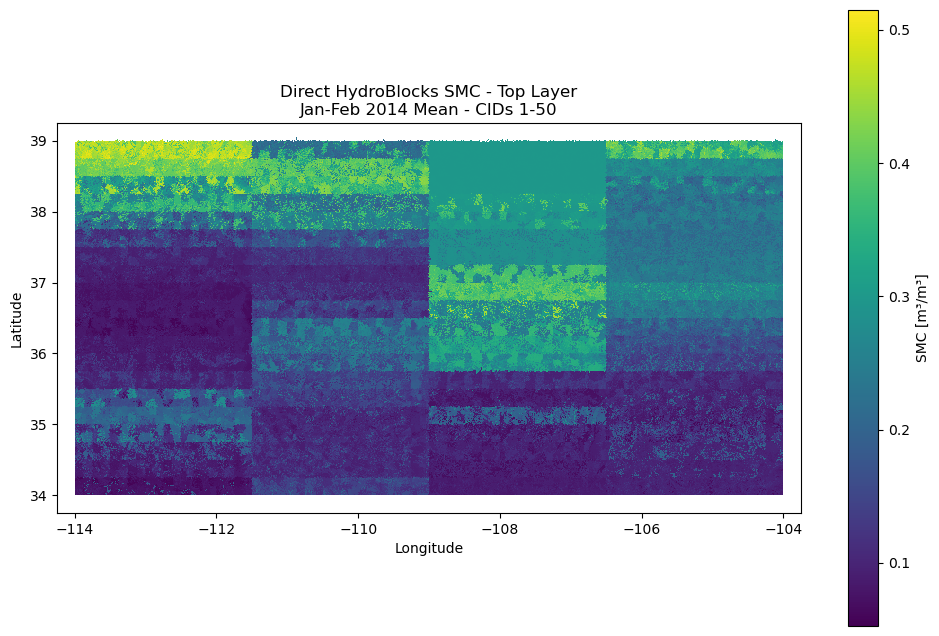

In [1]:
#!/usr/bin/env python3

import os
import subprocess
import numpy as np
import netCDF4 as nc
import rasterio
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

edir = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_100hru_100bh_bug_checking"
)

output_data = os.path.join(edir, "output_data")
hru_dir = os.path.join(edir, "postprocess", "hrus")

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)

os.makedirs(outputdir, exist_ok=True)


# ============================================================
# SETTINGS
# ============================================================

var = "smc"

# Top soil layer
layer = 0

# Direct HydroBlocks output file
stem = "2014-01-01"

# Time window
start_date = "2014-01-01"
end_date = "2014-02-28"

# First few CIDs
cid_list = range(1, 801)

# Aggregation
agg = "mean"


# ============================================================
# OUTPUT FILES
# ============================================================

tile_output_dir = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50_tiles"
)

os.makedirs(tile_output_dir, exist_ok=True)

vrt_file = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.vrt"
)

merged_tif = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.tif"
)

plot_file = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.png"
)


# ============================================================
# FUNCTION: GET TIME INDICES
# ============================================================

def window_indices(fp, start, end):

    """
    Select timesteps using the HydroBlocks metadata/date variable.

    date is in hours since 1900-01-01.
    """

    import datetime as dt

    dvar = fp.groups["metadata"].variables["date"]

    hours = np.asarray(
        dvar[:],
        dtype=np.float64
    )

    epoch = dt.datetime(1900, 1, 1)

    t0 = (
        dt.datetime.strptime(start, "%Y-%m-%d") - epoch
    ).total_seconds() / 3600.0

    # Inclusive end date
    t1 = (
        dt.datetime.strptime(end, "%Y-%m-%d")
        + dt.timedelta(days=1)
        - epoch
    ).total_seconds() / 3600.0

    idx = np.where(
        (hours >= t0) &
        (hours < t1)
    )[0]

    return idx


# ============================================================
# FUNCTION: PROCESS ONE CID
# ============================================================

def render_one(cid):

    print("=" * 60)
    print(f"Processing CID {cid}", flush=True)

    # --------------------------------------------------------
    # Files
    # --------------------------------------------------------

    ncpath = os.path.join(
        output_data,
        str(cid),
        stem + ".nc"
    )

    hrupath = os.path.join(
        hru_dir,
        f"{cid}.tif"
    )

    if not os.path.exists(ncpath):

        print(
            f"  Missing model file: {ncpath}",
            flush=True
        )

        return None

    if not os.path.exists(hrupath):

        print(
            f"  Missing HRU raster: {hrupath}",
            flush=True
        )

        return None


    # --------------------------------------------------------
    # Read model output
    # --------------------------------------------------------

    fp = nc.Dataset(ncpath, "r")

    try:

        fp.set_auto_mask(False)

        idx = window_indices(
            fp,
            start_date,
            end_date
        )

        if idx.size == 0:

            print(
                f"  No timesteps between "
                f"{start_date} and {end_date}",
                flush=True
            )

            return None


        # ----------------------------------------------------
        # Read variable
        # ----------------------------------------------------

        v = fp.groups["data"].variables[var]

        print(
            "  Variable dimensions:",
            v.dimensions,
            flush=True
        )

        print(
            "  Variable shape:",
            v.shape,
            flush=True
        )


        # ----------------------------------------------------
        # Read selected time window
        # ----------------------------------------------------

        raw = v[
            idx[0]:idx[-1] + 1,
            ...
        ]

        sub = np.asarray(
            raw,
            dtype=np.float32
        )


        # ----------------------------------------------------
        # Make sure selected indices match
        # ----------------------------------------------------

        if idx.size != sub.shape[0]:

            sub = sub[
                idx - idx[0]
            ]


        # ----------------------------------------------------
        # Select soil layer
        # ----------------------------------------------------

        if layer is not None:

            if sub.ndim != 3:

                print(
                    f"  ERROR: {var} is {sub.ndim}-D "
                    f"but layer was requested",
                    flush=True
                )

                return None

            # smc(time, hru, soil)
            sub = sub[:, :, layer]

        elif sub.ndim != 2:

            print(
                f"  ERROR: {var} is {sub.ndim}-D. "
                f"A layer must be specified.",
                flush=True
            )

            return None


        nt_used = sub.shape[0]

        print(
            f"  Timesteps selected: {nt_used}",
            flush=True
        )

        print(
            "  Selected data shape:",
            sub.shape,
            flush=True
        )


    finally:

        fp.close()


    # --------------------------------------------------------
    # Aggregate over time
    # --------------------------------------------------------

    with np.errstate(
        invalid="ignore",
        divide="ignore"
    ):

        if agg == "mean":

            vals = np.nanmean(
                sub,
                axis=0
            )

        elif agg == "max":

            vals = np.nanmax(
                sub,
                axis=0
            )

        elif agg == "min":

            vals = np.nanmin(
                sub,
                axis=0
            )

        elif agg == "sum":

            vals = np.nansum(
                sub,
                axis=0
            )

        else:

            raise ValueError(
                f"Unknown aggregation: {agg}"
            )


    vals = np.asarray(
        vals,
        dtype=np.float32
    )


    print(
        "  Number of HRU values:",
        vals.size,
        flush=True
    )

    print(
        "  HRU value min/max:",
        np.nanmin(vals),
        np.nanmax(vals),
        flush=True
    )


    # ========================================================
    # READ THIS CID'S OWN HRU RASTER
    # ========================================================

    with rasterio.open(hrupath) as src:

        hru = np.ascontiguousarray(
            src.read(
                1,
                masked=False
            )
        )

        profile = src.profile.copy()


    print(
        "  HRU raster shape:",
        hru.shape,
        flush=True
    )


    nodata = profile.get("nodata")

    if nodata is None:

        nodata = -9999.0


    # ========================================================
    # MAP HRU VALUES DIRECTLY TO TILE
    # ========================================================

    ids = hru.astype(
        np.int64
    )

    valid = (
        (hru != nodata)
        &
        (ids >= 0)
        &
        (ids < vals.size)
    )


    print(
        "  Valid raster pixels:",
        np.sum(valid),
        flush=True
    )


    if not valid.any():

        print(
            f"  CID {cid}: no valid HRU pixels",
            flush=True
        )

        return None


    # --------------------------------------------------------
    # Output tile
    # --------------------------------------------------------

    out = np.full(
        hru.shape,
        -9999.0,
        dtype=np.float32
    )


    # Critical mapping:
    #
    # raster HRU ID -> model HRU value
    #
    out[valid] = vals[
        ids[valid]
    ]


    # ========================================================
    # WRITE THIS CID'S GEOTIFF
    # ========================================================

    profile.update(
        dtype="float32",
        count=1,
        nodata=-9999.0,
        compress="deflate",
        tiled=True
    )


    tile_path = os.path.join(
        tile_output_dir,
        f"{cid}.tif"
    )


    with rasterio.open(
        tile_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            out,
            1
        )


    print(
        f"  Wrote: {tile_path}",
        flush=True
    )


    return {
        "cid": cid,
        "file": tile_path,
        "nt": nt_used,
        "min": float(np.nanmin(vals)),
        "max": float(np.nanmax(vals))
    }


# ============================================================
# PROCESS ALL SELECTED CIDS
# ============================================================

results = []

for cid in cid_list:

    result = render_one(cid)

    if result is not None:

        results.append(result)


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(
    "Requested CIDs:",
    len(list(cid_list))
)

print(
    "Successfully processed:",
    len(results)
)


if len(results) == 0:

    raise RuntimeError(
        "No CIDs were successfully processed."
    )


# ------------------------------------------------------------
# Check timestep count
# ------------------------------------------------------------

nt_seen = sorted(
    set(
        r["nt"]
        for r in results
    )
)


print(
    "Timesteps used per tile:",
    nt_seen
)


if len(nt_seen) > 1:

    print(
        "WARNING: timestep count is NOT uniform across tiles!"
    )


# ------------------------------------------------------------
# Value range
# ------------------------------------------------------------

global_min = min(
    r["min"]
    for r in results
)

global_max = max(
    r["max"]
    for r in results
)


print(
    "Value range across tiles:",
    global_min,
    "to",
    global_max
)


# ============================================================
# CREATE FILE LIST FOR GDAL
# ============================================================

list_file = os.path.join(
    tile_output_dir,
    "files.txt"
)


with open(
    list_file,
    "w"
) as fh:

    for result in sorted(
        results,
        key=lambda x: x["cid"]
    ):

        fh.write(
            result["file"] + "\n"
        )


# ============================================================
# BUILD VRT
# ============================================================

print("\nBuilding VRT...", flush=True)


subprocess.run(
    [
        "gdalbuildvrt",

        "-srcnodata",
        "-9999",

        "-vrtnodata",
        "-9999",

        "-input_file_list",
        list_file,

        vrt_file
    ],
    check=True
)


print(
    "Created VRT:",
    vrt_file,
    flush=True
)


# ============================================================
# CREATE MERGED GEOTIFF
# ============================================================

print(
    "\nCreating merged GeoTIFF...",
    flush=True
)


subprocess.run(
    [
        "gdal_translate",

        "-co",
        "COMPRESS=DEFLATE",

        "-co",
        "TILED=YES",

        "-co",
        "BIGTIFF=IF_SAFER",

        vrt_file,
        merged_tif
    ],
    check=True
)


print(
    "Created merged GeoTIFF:",
    merged_tif,
    flush=True
)


# ============================================================
# READ MERGED TIFF
# ============================================================

with rasterio.open(
    merged_tif
) as src:

    merged = src.read(
        1
    ).astype(
        np.float32
    )

    bounds = src.bounds


# Convert nodata to NaN only for plotting
merged[
    merged <= -9990
] = np.nan


print(
    "Merged raster shape:",
    merged.shape,
    flush=True
)

print(
    "Merged valid pixels:",
    np.sum(
        np.isfinite(
            merged
        )
    ),
    flush=True
)

print(
    "Merged min:",
    np.nanmin(
        merged
    ),
    flush=True
)

print(
    "Merged max:",
    np.nanmax(
        merged
    ),
    flush=True
)


# ============================================================
# PLOT
# ============================================================

extent = [
    bounds.left,
    bounds.right,
    bounds.bottom,
    bounds.top
]


fig, ax = plt.subplots(
    figsize=(12, 8)
)


im = ax.imshow(
    merged,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)


ax.set_title(
    "Direct HydroBlocks SMC - Top Layer\n"
    "Jan-Feb 2014 Mean - CIDs 1-50"
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)


cbar = plt.colorbar(
    im,
    ax=ax,
    label="SMC [m³/m³]"
)


plt.savefig(
    plot_file,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved plot:",
    plot_file,
    flush=True
)


plt.show()